In [4]:
from pathlib import Path

from safetensors.torch import load_file
from scipy.stats import entropy
import seaborn as sns

import torch

## Tensor inspection

This notebooks is used for inspecting the health of tensors generated in high-performance runs.

# Inspect stride 1

In [40]:
probs_1 = load_file("/users/cn/itrujnara/genomes-project/infer_chromosome/one_chunk/tensors/chunk0_embeddings_context8192_stride1.safetensors")["embeddings"]
probs_16 = load_file("/users/cn/itrujnara/genomes-project/infer_chromosome/one_chunk/tensors/evo2_7b_embeddings_context8192_stride16.safetensors")["embeddings"][:32768]

In [41]:
probs_1

tensor([[ 0.0142, -0.0189,  0.0356,  ...,  0.0068,  0.0095, -0.0093],
        [ 0.0143, -0.0189,  0.0342,  ...,  0.0069,  0.0098, -0.0095],
        [ 0.0148, -0.0197,  0.0304,  ...,  0.0074,  0.0104, -0.0100],
        ...,
        [ 0.0148, -0.0165,  0.0284,  ...,  0.0071,  0.0101, -0.0099],
        [ 0.0153, -0.0167,  0.0283,  ...,  0.0073,  0.0105, -0.0102],
        [ 0.0150, -0.0168,  0.0291,  ...,  0.0071,  0.0103, -0.0100]])

In [42]:
probs_16

tensor([[ 0.0142, -0.0188,  0.0356,  ...,  0.0068,  0.0095, -0.0093],
        [ 0.0143, -0.0188,  0.0342,  ...,  0.0069,  0.0098, -0.0095],
        [ 0.0148, -0.0195,  0.0304,  ...,  0.0074,  0.0104, -0.0100],
        ...,
        [ 0.0148, -0.0167,  0.0284,  ...,  0.0071,  0.0101, -0.0099],
        [ 0.0153, -0.0167,  0.0284,  ...,  0.0073,  0.0106, -0.0102],
        [ 0.0150, -0.0168,  0.0289,  ...,  0.0071,  0.0103, -0.0100]])

In [43]:
((probs_1 - probs_16) ** 2).sum(dim=1).sqrt().mean()

tensor(0.0880)

# Inspect one 1M chunk

In [5]:
basepath = Path("/no_backup/rg/itrujnara/infer_chromosome/tensors")

In [6]:
probs = load_file(basepath / "ch38_chr21_12484608_13533184_probs.safetensors")["probs"]

In [7]:
probs

tensor([[1.7477e-03, 2.5628e-03, 1.4043e-03, 9.9429e-01],
        [9.0145e-04, 1.4979e-03, 1.2913e-03, 9.9631e-01],
        [1.2596e-03, 2.8607e-03, 9.8095e-04, 9.9490e-01],
        ...,
        [2.3070e-01, 1.8024e-01, 2.2781e-01, 3.6126e-01],
        [2.8844e-01, 1.7359e-01, 2.0791e-01, 3.3006e-01],
        [2.4295e-01, 1.7363e-01, 2.6501e-01, 3.1842e-01]])

In [8]:
ic = 2 - entropy(probs, axis=1, base=2)

In [9]:
ic

array([1.9404025 , 1.9591202 , 1.9465514 , ..., 0.04948938, 0.04515779,
       0.03206682], dtype=float32)

In [17]:
sns.set_theme()

<Axes: >

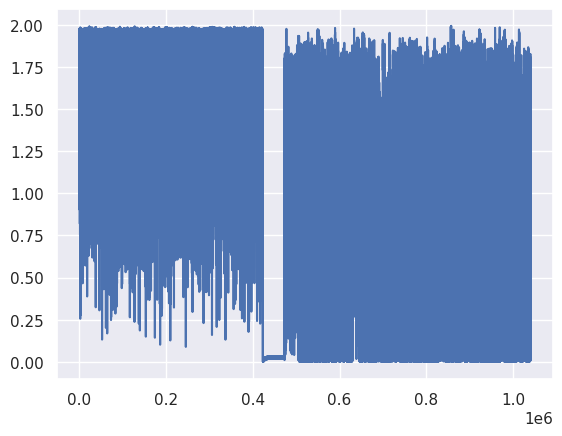

In [18]:
sns.lineplot(ic)

# Combine tensors

In [2]:
size = 2**20
stride = size - 8192
chr_size = 46709983
print(size,stride)

1048576 1040384


In [51]:
chunks = []

for start in range(0,chr_size,stride):
    end = min(start + size, chr_size)
    filename = f"ch38_chr21_{start}_{end}_probs.safetensors"
    try:
        chunk_probs = load_file(basepath / filename)["probs"]
        chunks.append(chunk_probs)
    except FileNotFoundError:
        print(filename + " not found")

ch38_chr21_0_1048576_probs.safetensors not found
ch38_chr21_1040384_2088960_probs.safetensors not found
ch38_chr21_2080768_3129344_probs.safetensors not found
ch38_chr21_3121152_4169728_probs.safetensors not found
ch38_chr21_4161536_5210112_probs.safetensors not found
ch38_chr21_13524992_14573568_probs.safetensors not found
ch38_chr21_17686528_18735104_probs.safetensors not found
ch38_chr21_18726912_19775488_probs.safetensors not found
ch38_chr21_19767296_20815872_probs.safetensors not found
ch38_chr21_20807680_21856256_probs.safetensors not found
ch38_chr21_21848064_22896640_probs.safetensors not found
ch38_chr21_22888448_23937024_probs.safetensors not found
ch38_chr21_23928832_24977408_probs.safetensors not found
ch38_chr21_24969216_26017792_probs.safetensors not found
ch38_chr21_26009600_27058176_probs.safetensors not found
ch38_chr21_27049984_28098560_probs.safetensors not found
ch38_chr21_28090368_29138944_probs.safetensors not found
ch38_chr21_29130752_30179328_probs.safetensors 

In [52]:
probs = torch.cat(chunks)

In [53]:
probs.shape

torch.Size([11444224, 4])

In [54]:
ic = 2 - entropy(probs, axis=1, base=2)

<Axes: >

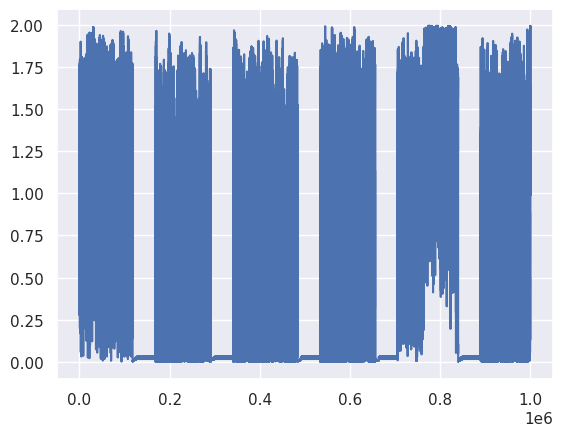

In [55]:
sns.lineplot(ic[2000000:3000000])

<Axes: ylabel='Count'>

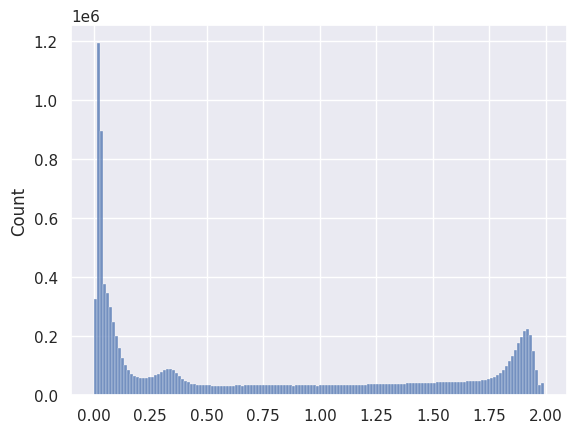

In [56]:
sns.histplot(ic)

<Axes: >

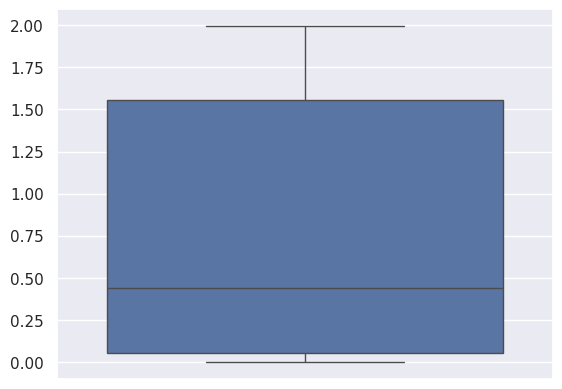

In [57]:
sns.boxplot(ic)

In [58]:
(ic > 1.5).sum() / ic.shape[0]

np.float64(0.26488462651552436)